# Evaluate distance based confidence predictor performance

In [1]:
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
with open('data/logs/train_confidence_predictor.log') as fh:
    training_log = fh.read()

In [3]:
print(training_log)

2025-04-01 18:49:11,454 - INFO: Parameter: training_data='data/processed/sequences.h5'
2025-04-01 18:49:11,455 - INFO: Parameter: output='models/ConfidencePredictor/model.onnx'
2025-04-01 18:49:11,455 - INFO: Parameter: test_size=0.15
2025-04-01 18:49:11,455 - INFO: Parameter: seed=123
2025-04-01 18:49:11,455 - INFO: Parameter: log_level='info'
2025-04-01 18:49:11,455 - INFO: Parameter: log_file='data/logs/train_confidence_predictor.log'
2025-04-01 18:49:11,455 - INFO: Loading data...
2025-04-01 18:49:15,433 - INFO: Computing distances
2025-04-01 19:42:05,327 - INFO: Test indices: [53811, 55025, 14604, 22284, 67165, 4921, 79970, 25753, 70198, 5689, 22309, 76028, 30488, 40939, 65349, 29954, 60218, 68023, 48885, 58750, 73446, 51749, 377, 58058, 23183, 51022, 14472, 74470, 3116, 4235, 77236, 18467, 7008, 35038, 14671, 5285, 73260, 71958, 69473, 10951, 49399, 53249, 67792, 68370, 15419, 44112, 71331, 51076, 46928, 3248, 15424, 73320, 28322, 25803, 15207, 57893, 37985, 22171, 6087, 48362, 8

In [4]:
folds = [int(fold) for fold in re.findall(r'INFO: Starting model for fold (\d+)', training_log, flags=re.MULTILINE)]

In [ ]:
r_squareds = [float(val) for val in re.findall(r'INFO: R\^2: (\d+\.\d+)', training_log, flags=re.MULTILINE)]

In [6]:
rmses = [float(val) for val in re.findall(r'INFO: RMSE: (\d+\.\d+)', training_log, flags=re.MULTILINE)]

In [7]:
results = pd.DataFrame(
    {
        'fold': folds,
        'r_squared': r_squareds,
        'rmse': rmses,
    }
)

results

,fold,r_squared,rmse
0,1,0.976121,0.023371
1,2,0.976043,0.023791
2,3,0.973950,0.021122
3,4,0.975867,0.024486
4,5,0.976649,0.023037


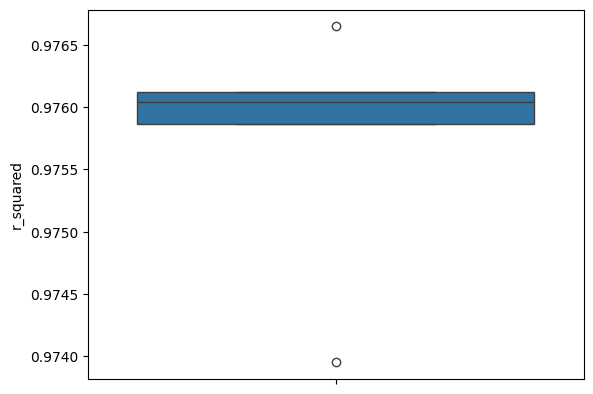

count    5.000000
mean     0.975726
std      0.001035
min      0.973950
25%      0.975867
50%      0.976043
75%      0.976121
max      0.976649
Name: r_squared, dtype: float64

In [8]:
sns.boxplot(results, y='r_squared')

plt.show()
results['r_squared'].describe()

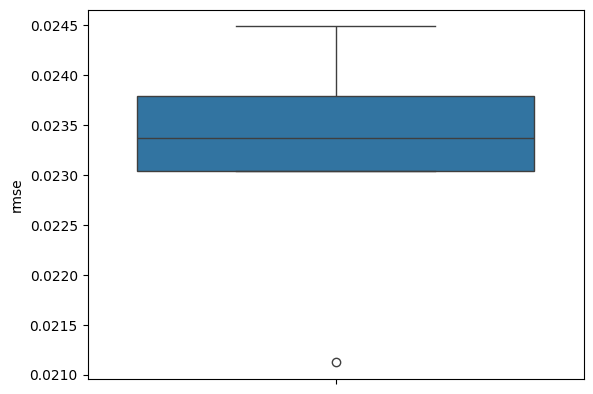

count    5.000000
mean     0.023161
std      0.001262
min      0.021122
25%      0.023037
50%      0.023371
75%      0.023791
max      0.024486
Name: rmse, dtype: float64

In [9]:
sns.boxplot(results, y='rmse')

plt.show()
results['rmse'].describe()